In [46]:
# ============================================================
# IMDB SENTIMENT ANALYSIS: WORD2VEC + GRU VS SVM + TF-IDF
# Dataset: TensorFlow Datasets imdb_reviews/plain_text
# ============================================================

# If needed, uncomment these:
#!pip install tensorflow-datasets
#!pip install gensim
#!pip install importlib_resources

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Bidirectional

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib


In [47]:
# ============================================================
# 1. SET RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [48]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

MAX_WORDS = 20000          # Maximum vocabulary size for GRU tokenizer
MAX_LEN = 300              # Maximum review length
WORD2VEC_SIZE = 100        # Word2Vec embedding dimension
VALIDATION_SIZE = 0.2      # 20% of training set used for validation

GRU_MODEL_PATH = "best_word2vec_gru_model.keras"
SVM_MODEL_PATH = "best_svm_tfidf_model.pkl"


In [49]:
# ============================================================
# 3. LOAD IMDB DATASET FROM TENSORFLOW DATASETS
# ============================================================

(ds_train, ds_test), ds_info = tfds.load(
    "imdb_reviews/plain_text",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print(ds_info)

print("\nDataset Features:")
print(ds_info.features)

print("\nTrain examples:", ds_info.splits["train"].num_examples)
print("Test examples :", ds_info.splits["test"].num_examples)


tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='C:\\Users\\jwts1\\tensorflow_datasets\\imdb_reviews\\plain_text\\1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <

In [50]:
# ============================================================
# 4. CONVERT TFDS DATASET TO PANDAS DATAFRAME
# ============================================================

def tfds_to_dataframe(tf_dataset):
    texts = []
    labels = []

    for text, label in tf_dataset:
        texts.append(text.numpy().decode("utf-8"))
        labels.append(int(label.numpy()))

    return pd.DataFrame({
        "text": texts,
        "label": labels
    })


train_df = tfds_to_dataframe(ds_train)
test_df = tfds_to_dataframe(ds_test)

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nExample review:")
print(train_df["text"].iloc[0][:500])
print("Label:", train_df["label"].iloc[0])



Train shape: (25000, 2)
Test shape : (25000, 2)

Example review:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but
Label: 0


In [51]:
# ============================================================
# 5. BASIC TEXT PREPROCESSING
# ============================================================

def clean_text(text):
    text = text.lower()

    # Remove HTML line breaks from IMDb text
    text = re.sub(r"<br\s*/?>", " ", text)

    # Remove punctuation and symbols, keep letters/numbers/spaces
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("\nCleaned example:")
print(train_df["clean_text"].iloc[0][:500])



Cleaned example:
this was an absolutely terrible movie don t be lured in by christopher walken or michael ironside both are great actors but this must simply be their worst role in history even their great acting could not redeem this movie s ridiculous storyline this movie is an early nineties us propaganda piece the most pathetic scenes were those when the columbian rebels were making their cases for revolutions maria conchita alonso appeared phony and her pseudo love affair with walken was nothing but a pathe


In [52]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np

# Convert text and labels into normal Python/NumPy objects
x_train_text_full = train_df["clean_text"].astype(str).tolist()
y_train_full = train_df["label"].astype(int).to_numpy()

x_test_text = test_df["clean_text"].astype(str).tolist()
y_test = test_df["label"].astype(int).to_numpy()

x_train_text, x_val_text, y_train, y_val = train_test_split(
    x_train_text_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_train_full
)

print("Training size   :", len(x_train_text))
print("Validation size :", len(x_val_text))
print("Testing size    :", len(x_test_text))

print("\nExample training text:")
print(x_train_text[0][:300])
print("Label:", y_train[0])

print("\nSample Training Review")
print("=" * 80)
print(x_train_text[0][:1000])
print("\nLabel:", y_train[0], "(0 = Negative, 1 = Positive)")

print("\nSample Validation Review")
print("=" * 80)
print(x_val_text[0][:1000])
print("\nLabel:", y_val[0], "(0 = Negative, 1 = Positive)")

print("\nSample Test Review")
print("=" * 80)
print(x_test_text[0][:1000])
print("\nLabel:", y_test[0], "(0 = Negative, 1 = Positive)")

Training size   : 20000
Validation size : 5000
Testing size    : 25000

Example training text:
the latest film by the spanish director agusti villaronga is a study on how children that experience violence and isolation within their remote community develop into troubled young adults that need certain psychic tools to deal with their hidden mental frailty whether these tools are religion follo
Label: 1

Sample Training Review
the latest film by the spanish director agusti villaronga is a study on how children that experience violence and isolation within their remote community develop into troubled young adults that need certain psychic tools to deal with their hidden mental frailty whether these tools are religion followed to a fanatical level caring for others or simply putting on a macho image whilst engaging as a male prostitute villaronga creates a successful examination of how these vices affect three teenagers living in spain under franco the three witness the disturbing double d

In [53]:
# ============================================================
# 7. TOKENISATION AND PADDING FOR GRU
# ============================================================

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(x_train_text)

x_train_seq = tokenizer.texts_to_sequences(x_train_text)
x_val_seq = tokenizer.texts_to_sequences(x_val_text)
x_test_seq = tokenizer.texts_to_sequences(x_test_text)

x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_val_pad = pad_sequences(
    x_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("\nPadded train shape:", x_train_pad.shape)
print("Padded val shape  :", x_val_pad.shape)
print("Padded test shape :", x_test_pad.shape)



Padded train shape: (20000, 300)
Padded val shape  : (5000, 300)
Padded test shape : (25000, 300)


In [54]:
# ============================================================
# 8. TRAIN WORD2VEC MODEL
# ============================================================

x_train_tokens = [review.split() for review in x_train_text]

word2vec_model = Word2Vec(
    sentences=x_train_tokens,
    vector_size=WORD2VEC_SIZE,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=SEED
)

print("\nWord2Vec vocabulary size:", len(word2vec_model.wv))


Word2Vec vocabulary size: 68358


In [55]:
# ============================================================
# 9. CREATE WORD2VEC EMBEDDING MATRIX FOR GRU
# ============================================================

word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, WORD2VEC_SIZE))

for word, i in word_index.items():
    if i < MAX_WORDS:
        if word in word2vec_model.wv:
            embedding_matrix[i] = word2vec_model.wv[word]

print("Embedding matrix shape:", embedding_matrix.shape)


Embedding matrix shape: (20000, 100)


In [56]:
# ============================================================
# 10. BUILD GRU MODEL FUNCTION
# ============================================================

def build_gru_model(gru_units=128, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential()

    model.add(
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=WORD2VEC_SIZE,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True,
            mask_zero=True
        )
    )

    model.add(SpatialDropout1D(dropout_rate))

    model.add(
        Bidirectional(
            GRU(
                units=gru_units,
                dropout=dropout_rate,
                recurrent_dropout=0.0
            )
        )
    )

    model.add(Dropout(dropout_rate))

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [57]:
# ============================================================
# 11. RANDOM SEARCH TUNING FOR GRU
# ============================================================

gru_param_grid = [
    {
        "gru_units": 64,
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "gru_units": 64,
        "dropout_rate": 0.3,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "gru_units": 128,
        "dropout_rate": 0.3,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "gru_units": 128,
        "dropout_rate": 0.4,
        "learning_rate": 0.001,
        "batch_size": 64
    },
    {
        "gru_units": 128,
        "dropout_rate": 0.3,
        "learning_rate": 0.0005,
        "batch_size": 64
    },
    {
        "gru_units": 256,
        "dropout_rate": 0.3,
        "learning_rate": 0.0005,
        "batch_size": 64
    }
]

N_TRIALS = 6
EPOCHS_TUNING = 3

selected_params = random.sample(gru_param_grid, N_TRIALS)

gru_tuning_results = []

print("\nStarting GRU Random Search Tuning...")

for trial_num, params in enumerate(selected_params, start=1):
    print(f"\nTrial {trial_num}/{N_TRIALS}")
    print(params)

    model = build_gru_model(
        gru_units=params["gru_units"],
        dropout_rate=params["dropout_rate"],
        learning_rate=params["learning_rate"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_pad,
        y_train,
        validation_data=(x_val_pad, y_val),
        epochs=EPOCHS_TUNING,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=1
    )

    val_probs = model.predict(x_val_pad)
    val_preds = (val_probs > 0.5).astype("int32").ravel()

    val_accuracy = accuracy_score(y_val, val_preds)
    val_precision = precision_score(y_val, val_preds)
    val_recall = recall_score(y_val, val_preds)
    val_f1 = f1_score(y_val, val_preds)

    gru_tuning_results.append({
        "trial": trial_num,
        "gru_units": params["gru_units"],
        "dropout_rate": params["dropout_rate"],
        "learning_rate": params["learning_rate"],
        "batch_size": params["batch_size"],
        "val_accuracy": val_accuracy,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1
    })

gru_tuning_df = pd.DataFrame(gru_tuning_results)
gru_tuning_df = gru_tuning_df.sort_values(by="val_f1", ascending=False)

print("\nGRU Tuning Results:")
display(gru_tuning_df)

best_gru_params = gru_tuning_df.iloc[0].to_dict()

print("\nBest GRU Parameters Based on Validation F1-score:")
print(best_gru_params)




Starting GRU Random Search Tuning...

Trial 1/6
{'gru_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
Epoch 1/3


c:\Users\jwts1\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.6297 - loss: 0.6361 - val_accuracy: 0.7716 - val_loss: 0.5290
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.7562 - loss: 0.5030 - val_accuracy: 0.8328 - val_loss: 0.3915
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.8534 - loss: 0.3461 - val_accuracy: 0.8898 - val_loss: 0.2678
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 295ms/step

Trial 2/6
{'gru_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
Epoch 1/3


c:\Users\jwts1\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 270ms/step - accuracy: 0.6908 - loss: 0.5684 - val_accuracy: 0.8354 - val_loss: 0.3769
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 267ms/step - accuracy: 0.8636 - loss: 0.3220 - val_accuracy: 0.8912 - val_loss: 0.2650
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 286ms/step - accuracy: 0.9129 - loss: 0.2241 - val_accuracy: 0.8988 - val_loss: 0.2658
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step

Trial 3/6
{'gru_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
Epoch 1/3


...

313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 256ms/step - accuracy: 0.6205 - loss: 0.6398 - val_accuracy: 0.7852 - val_loss: 0.4679
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.8145 - loss: 0.4037 - val_accuracy: 0.8884 - val_loss: 0.2788
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.8913 - loss: 0.2735 - val_accuracy: 0.8964 - val_loss: 0.2623
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step

Trial 6/6
{'gru_units': 128, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64}
Epoch 1/3


c:\Users\jwts1\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 183s 569ms/step - accuracy: 0.5926 - loss: 0.6629 - val_accuracy: 0.7118 - val_loss: 0.5464
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 182s 582ms/step - accuracy: 0.7656 - loss: 0.4892 - val_accuracy: 0.8670 - val_loss: 0.3258
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 651ms/step - accuracy: 0.8663 - loss: 0.3224 - val_accuracy: 0.8932 - val_loss: 0.2653
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step

GRU Tuning Results:


,trial,gru_units,dropout_rate,learning_rate,batch_size,val_accuracy,val_precision,val_recall,val_f1
4,5,64,0.3,0.0010,64,0.8964,0.870883,0.9308,0.899845
3,4,128,0.3,0.0010,64,0.8964,0.871439,0.9300,0.899768
5,6,128,0.4,0.0010,64,0.8932,0.870384,0.9240,0.896391
1,2,64,0.2,0.0010,64,0.8912,0.884132,0.9004,0.892192
0,1,256,0.3,0.0005,64,0.8898,0.894056,0.8844,0.889202
2,3,128,0.3,0.0005,64,0.8738,0.839448,0.9244,0.879878



Best GRU Parameters Based on Validation F1-score:
{'trial': 5.0, 'gru_units': 64.0, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64.0, 'val_accuracy': 0.8964, 'val_precision': 0.8708832335329342, 'val_recall': 0.9308, 'val_f1': 0.89984532095901}


In [58]:
# ============================================================
# 12. TRAIN FINAL GRU MODEL USING BEST PARAMETERS
# ============================================================

final_gru_model = build_gru_model(
    gru_units=int(best_gru_params["gru_units"]),
    dropout_rate=float(best_gru_params["dropout_rate"]),
    learning_rate=float(best_gru_params["learning_rate"])
)

checkpoint = ModelCheckpoint(
    GRU_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("\nTraining Final Word2Vec + GRU Model...")

gru_history = final_gru_model.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=15,
    batch_size=int(best_gru_params["batch_size"]),
    callbacks=[checkpoint],
    verbose=1
)



Training Final Word2Vec + GRU Model...
Epoch 1/15


c:\Users\jwts1\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5627 - loss: 0.6766
Epoch 1: val_loss improved from None to 0.47915, saving model to best_word2vec_gru_model.keras

Epoch 1: finished saving model to best_word2vec_gru_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 113s 349ms/step - accuracy: 0.6209 - loss: 0.6365 - val_accuracy: 0.7676 - val_loss: 0.4791
Epoch 2/15
 31/313 ━━━━━━━━━━━━━━━━━━━━ 1:15 268ms/step - accuracy: 0.7161 - loss: 0.5454

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 13. TRAIN SVM + TF-IDF BASELINE WITH RANDOMIZED SEARCH CV
# ============================================================

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("svm", LinearSVC(random_state=SEED))
])

svm_param_dist = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.8, 0.9, 1.0],
    "svm__C": [0.1, 0.5, 1, 2, 5]
}

svm_random_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

print("\nTraining and Tuning SVM + TF-IDF Baseline...")

svm_random_search.fit(x_train_text, y_train)

best_svm_model = svm_random_search.best_estimator_

print("\nBest SVM Parameters Based on Cross-Validation F1-score:")
print(svm_random_search.best_params_)

joblib.dump(best_svm_model, SVM_MODEL_PATH)



Training and Tuning SVM + TF-IDF Baseline...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best SVM Parameters Based on Cross-Validation F1-score:
{'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 1, 'tfidf__max_features': 10000, 'tfidf__max_df': 0.9, 'svm__C': 0.5}


['best_svm_tfidf_model.pkl']

In [ ]:
# ============================================================
# 14. LOAD BEST MODELS AND EVALUATE ON TEST SET
# ============================================================

best_gru_saved = load_model(GRU_MODEL_PATH)
best_svm_saved = joblib.load(SVM_MODEL_PATH)

# GRU predictions
gru_probs = best_gru_saved.predict(x_test_pad)
gru_preds = (gru_probs > 0.5).astype("int32").ravel()

# SVM predictions
svm_preds = best_svm_saved.predict(x_test_text)

782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step


In [ ]:
# ============================================================
# 15. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name} Test Results")
    print("=" * 50)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    ))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }


gru_results = evaluate_model("Word2Vec + GRU", y_test, gru_preds)
svm_results = evaluate_model("SVM + TF-IDF", y_test, svm_preds)


Word2Vec + GRU Test Results
Accuracy : 0.8641
Precision: 0.8923
Recall   : 0.8282
F1-score : 0.859

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.90      0.87     12500
    Positive       0.89      0.83      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000


SVM + TF-IDF Test Results
Accuracy : 0.8889
Precision: 0.8862
Recall   : 0.8923
F1-score : 0.8893

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89     12500
    Positive       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [ ]:
# ============================================================
# 16. FINAL MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame([gru_results, svm_results])
results_df = results_df.sort_values(by="F1-score", ascending=False)

print("\nFinal Model Comparison")
display(results_df)



Final Model Comparison


,Model,Accuracy,Precision,Recall,F1-score
1,SVM + TF-IDF,0.88888,0.886223,0.89232,0.889261
0,Word2Vec + GRU,0.86408,0.892260,0.82816,0.859016


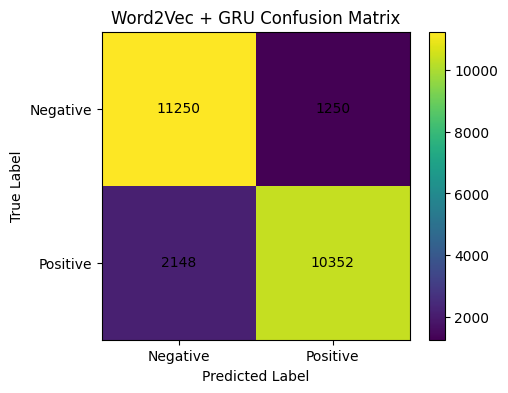

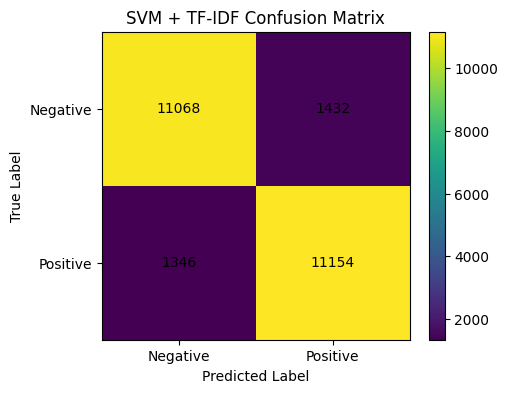

In [ ]:
# ============================================================
# 17. CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()


plot_confusion_matrix(y_test, gru_preds, "Word2Vec + GRU")
plot_confusion_matrix(y_test, svm_preds, "SVM + TF-IDF")


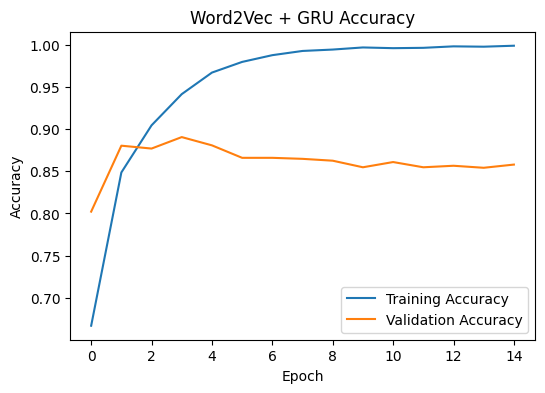

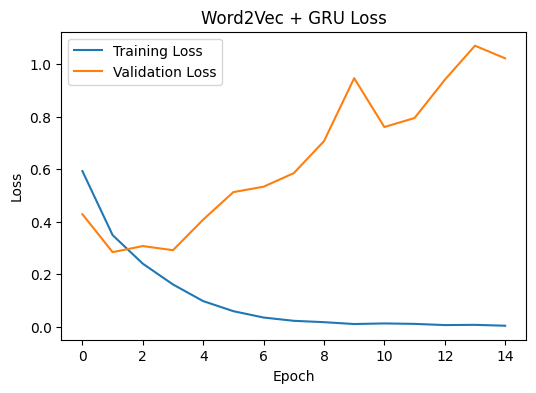

In [ ]:
# ============================================================
# 18. TRAINING CURVES FOR GRU
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(gru_history.history["accuracy"], label="Training Accuracy")
plt.plot(gru_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Word2Vec + GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")
plt.title("Word2Vec + GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 19. FINAL MODEL SELECTION BASED ON F1-SCORE
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1-score"]

print("\nFinal Selected Model")
print("=" * 50)
print("Best model based on F1-score:", best_model_name)
print("Best F1-score:", round(best_f1, 4))


Final Selected Model
Best model based on F1-score: SVM + TF-IDF
Best F1-score: 0.8893
